# CAB420 Assignment 1A Question 1: Regression
Simon Denman (s.denman@qut.edu.au)

## Overview

This notebook provides a brief template for CAB420 Assignment 1A, Question 1. It implements the data loading, and splitting the data into the predictors and response. You are to use the data splits defined here in your response.

The template also provides other suggestions around how to approach the problem.

Please make sure you read the assignment brief on canvas, and check the FAQ for other information.

**Note: File paths used in this template may need to change for your local machine. Please set these based on your local file system structure.**

In [120]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [121]:
import pandas as pd
import numpy as np

In [122]:
# load data
train = pd.read_csv('./data/Q1/communities_train.csv')
val = pd.read_csv('./data/Q1/communities_val.csv')
test = pd.read_csv('./data/Q1/communities_test.csv')

# Pull out X and y components of the data
# if you want to convert this data to numpy format, you can add .to_numpy() to the end of each row below
X_train = train.iloc[:,0:-1]
y_train = train.iloc[:,-1]
X_val = val.iloc[:,0:-1]
y_val = val.iloc[:,-1]
X_test = test.iloc[:,0:-1]
y_test = test.iloc[:,-1]

## Exploratory Data Analysis

The Exploratory Data Analysis informs the methodology, pre-processing and the final regression implementation

### Available Data

Exploring the available data will inform the later EDA

In [123]:
# See dataset shapes
display(
    pd.DataFrame(
        {
            "Dataset" : ["Train", "Validation", "Test"],
            "Total Shape": [train.shape, val.shape, test.shape],
            "X Shape": [X_train.shape, X_val.shape, X_test.shape],
            "y Shape": [y_train.shape, y_val.shape, y_test.shape]
        }
    )
)

,Dataset,Total Shape,X Shape,y Shape
0,Train,"(298, 101)","(298, 100)","(298,)"
1,Validation,"(298, 101)","(298, 100)","(298,)"
2,Test,"(299, 101)","(299, 100)","(299,)"


In [124]:
# Check columnn data types
display(
    pd.DataFrame(
        {
            "Dataset" : ["Train", "Validation", "Test"],
            "Total types": [train.dtypes.value_counts(), val.dtypes.value_counts(), test.dtypes.value_counts()],
            "X types": [X_train.dtypes.value_counts(), X_val.dtypes.value_counts(), X_test.dtypes.value_counts()],
            "y types": [y_train.dtype, y_val.dtype, y_test.dtype]
        }
    )
)

,Dataset,Total types,X types,y types
0,Train,"float64 101 Name: count, dtype: int64","float64 100 Name: count, dtype: int64",float64
1,Validation,"float64 101 Name: count, dtype: int64","float64 100 Name: count, dtype: int64",float64
2,Test,"float64 101 Name: count, dtype: int64","float64 100 Name: count, dtype: int64",float64


#### Interpreting Available Data

From the above cells it can be seen that all the data is already split into train, validation and test sets. Where every datapoint contains 100 floating point predictor variables and the target contains a single floating point output.

Referring to `./data/Q1/Communities_Info.txt`:

> *"[...] Many variables are included so that algorithms that select or learn weights for attributes could be tested. However, clearly unrelated attributes were not included; [...]"*

And the slack response by Simon: 

> *"The "just use as is" refers to not adding/removing terms. [...]"*

Removing / adding variables to the is therefore removed from the scope of this task.

Therefore, the template provides a very strong foundation for the task

### Check for data validity

Searching for NaN, null, inf or -inf values will inform later EDA and the later implementation

In [125]:
display(
    pd.DataFrame(
        {
            "Dataset" : ["Train", "Validation", "Test"],
            "Total null": [train.isnull().sum().sum(), val.isnull().sum().sum(), test.isnull().sum().sum()],
            "Total inf": [np.isinf(train).sum().sum(), np.isinf(val).sum().sum(), np.isinf(test).sum().sum()]
        }
    )
)

,Dataset,Total null,Total inf
0,Train,0,0
1,Validation,0,0
2,Test,0,0


#### Interpreting the validity of the data

As there are no invalid values in any of the data this removes the need to handle invalid data in the task.

### Data distributions

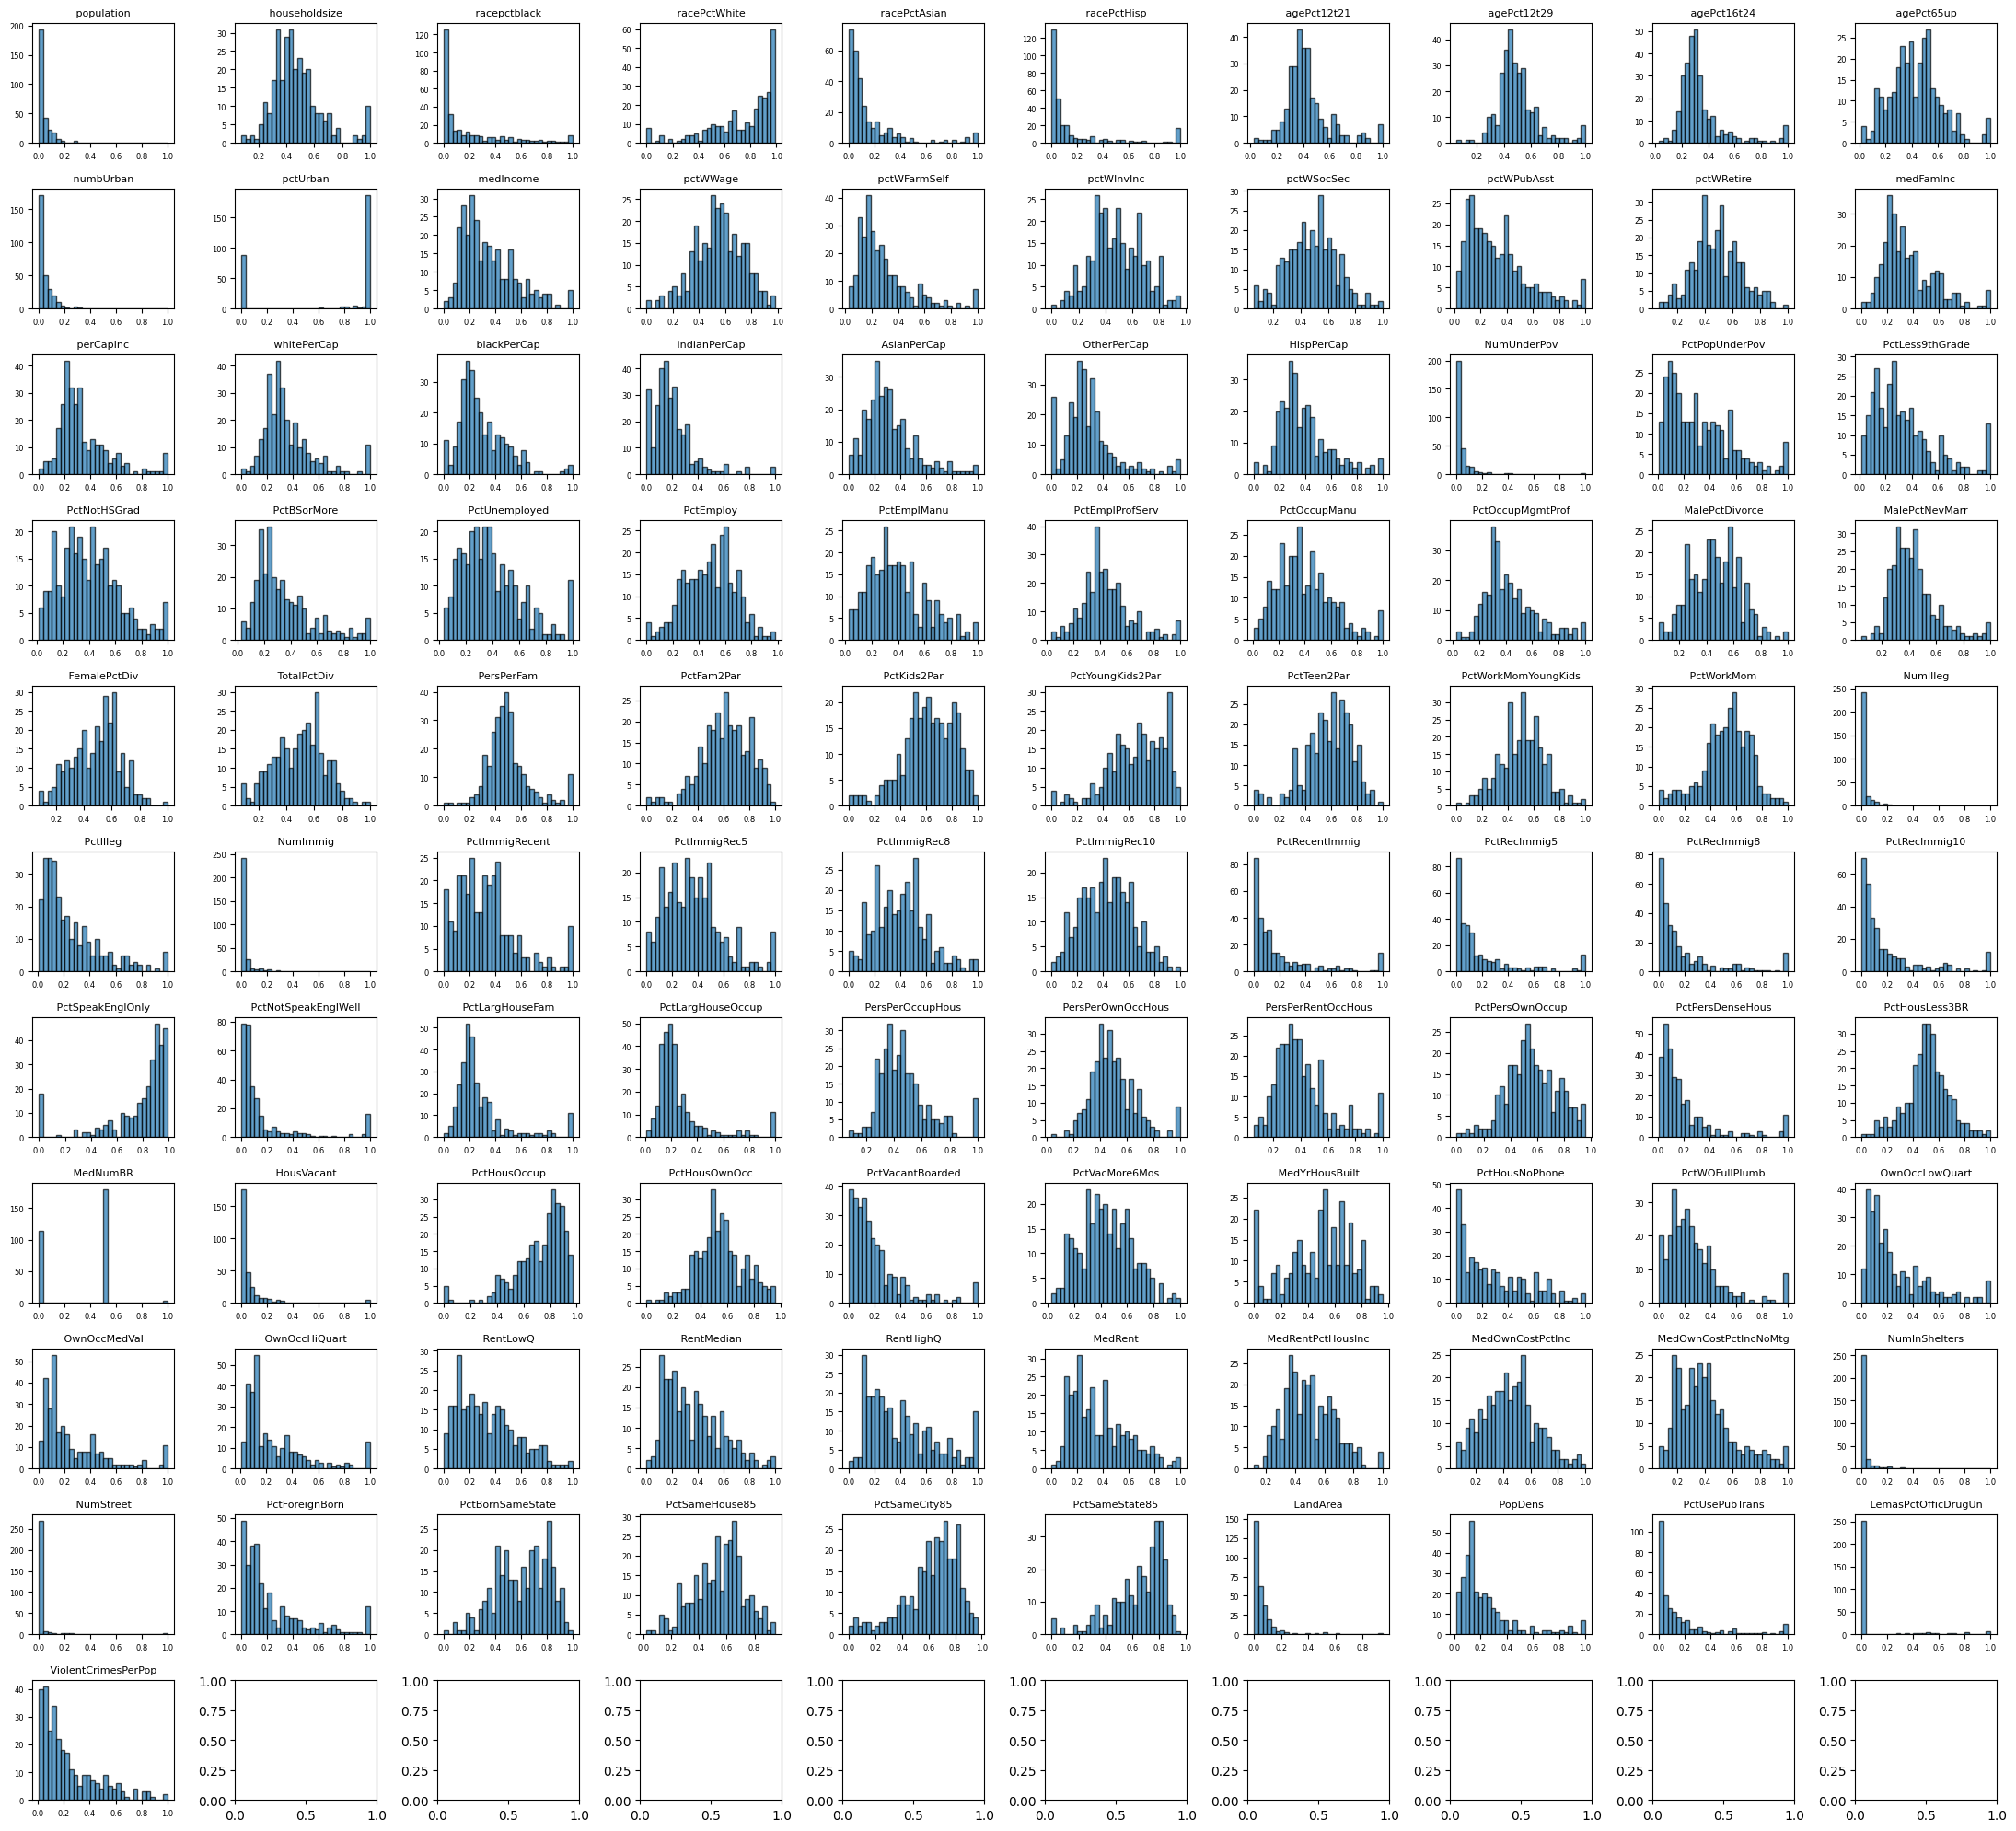

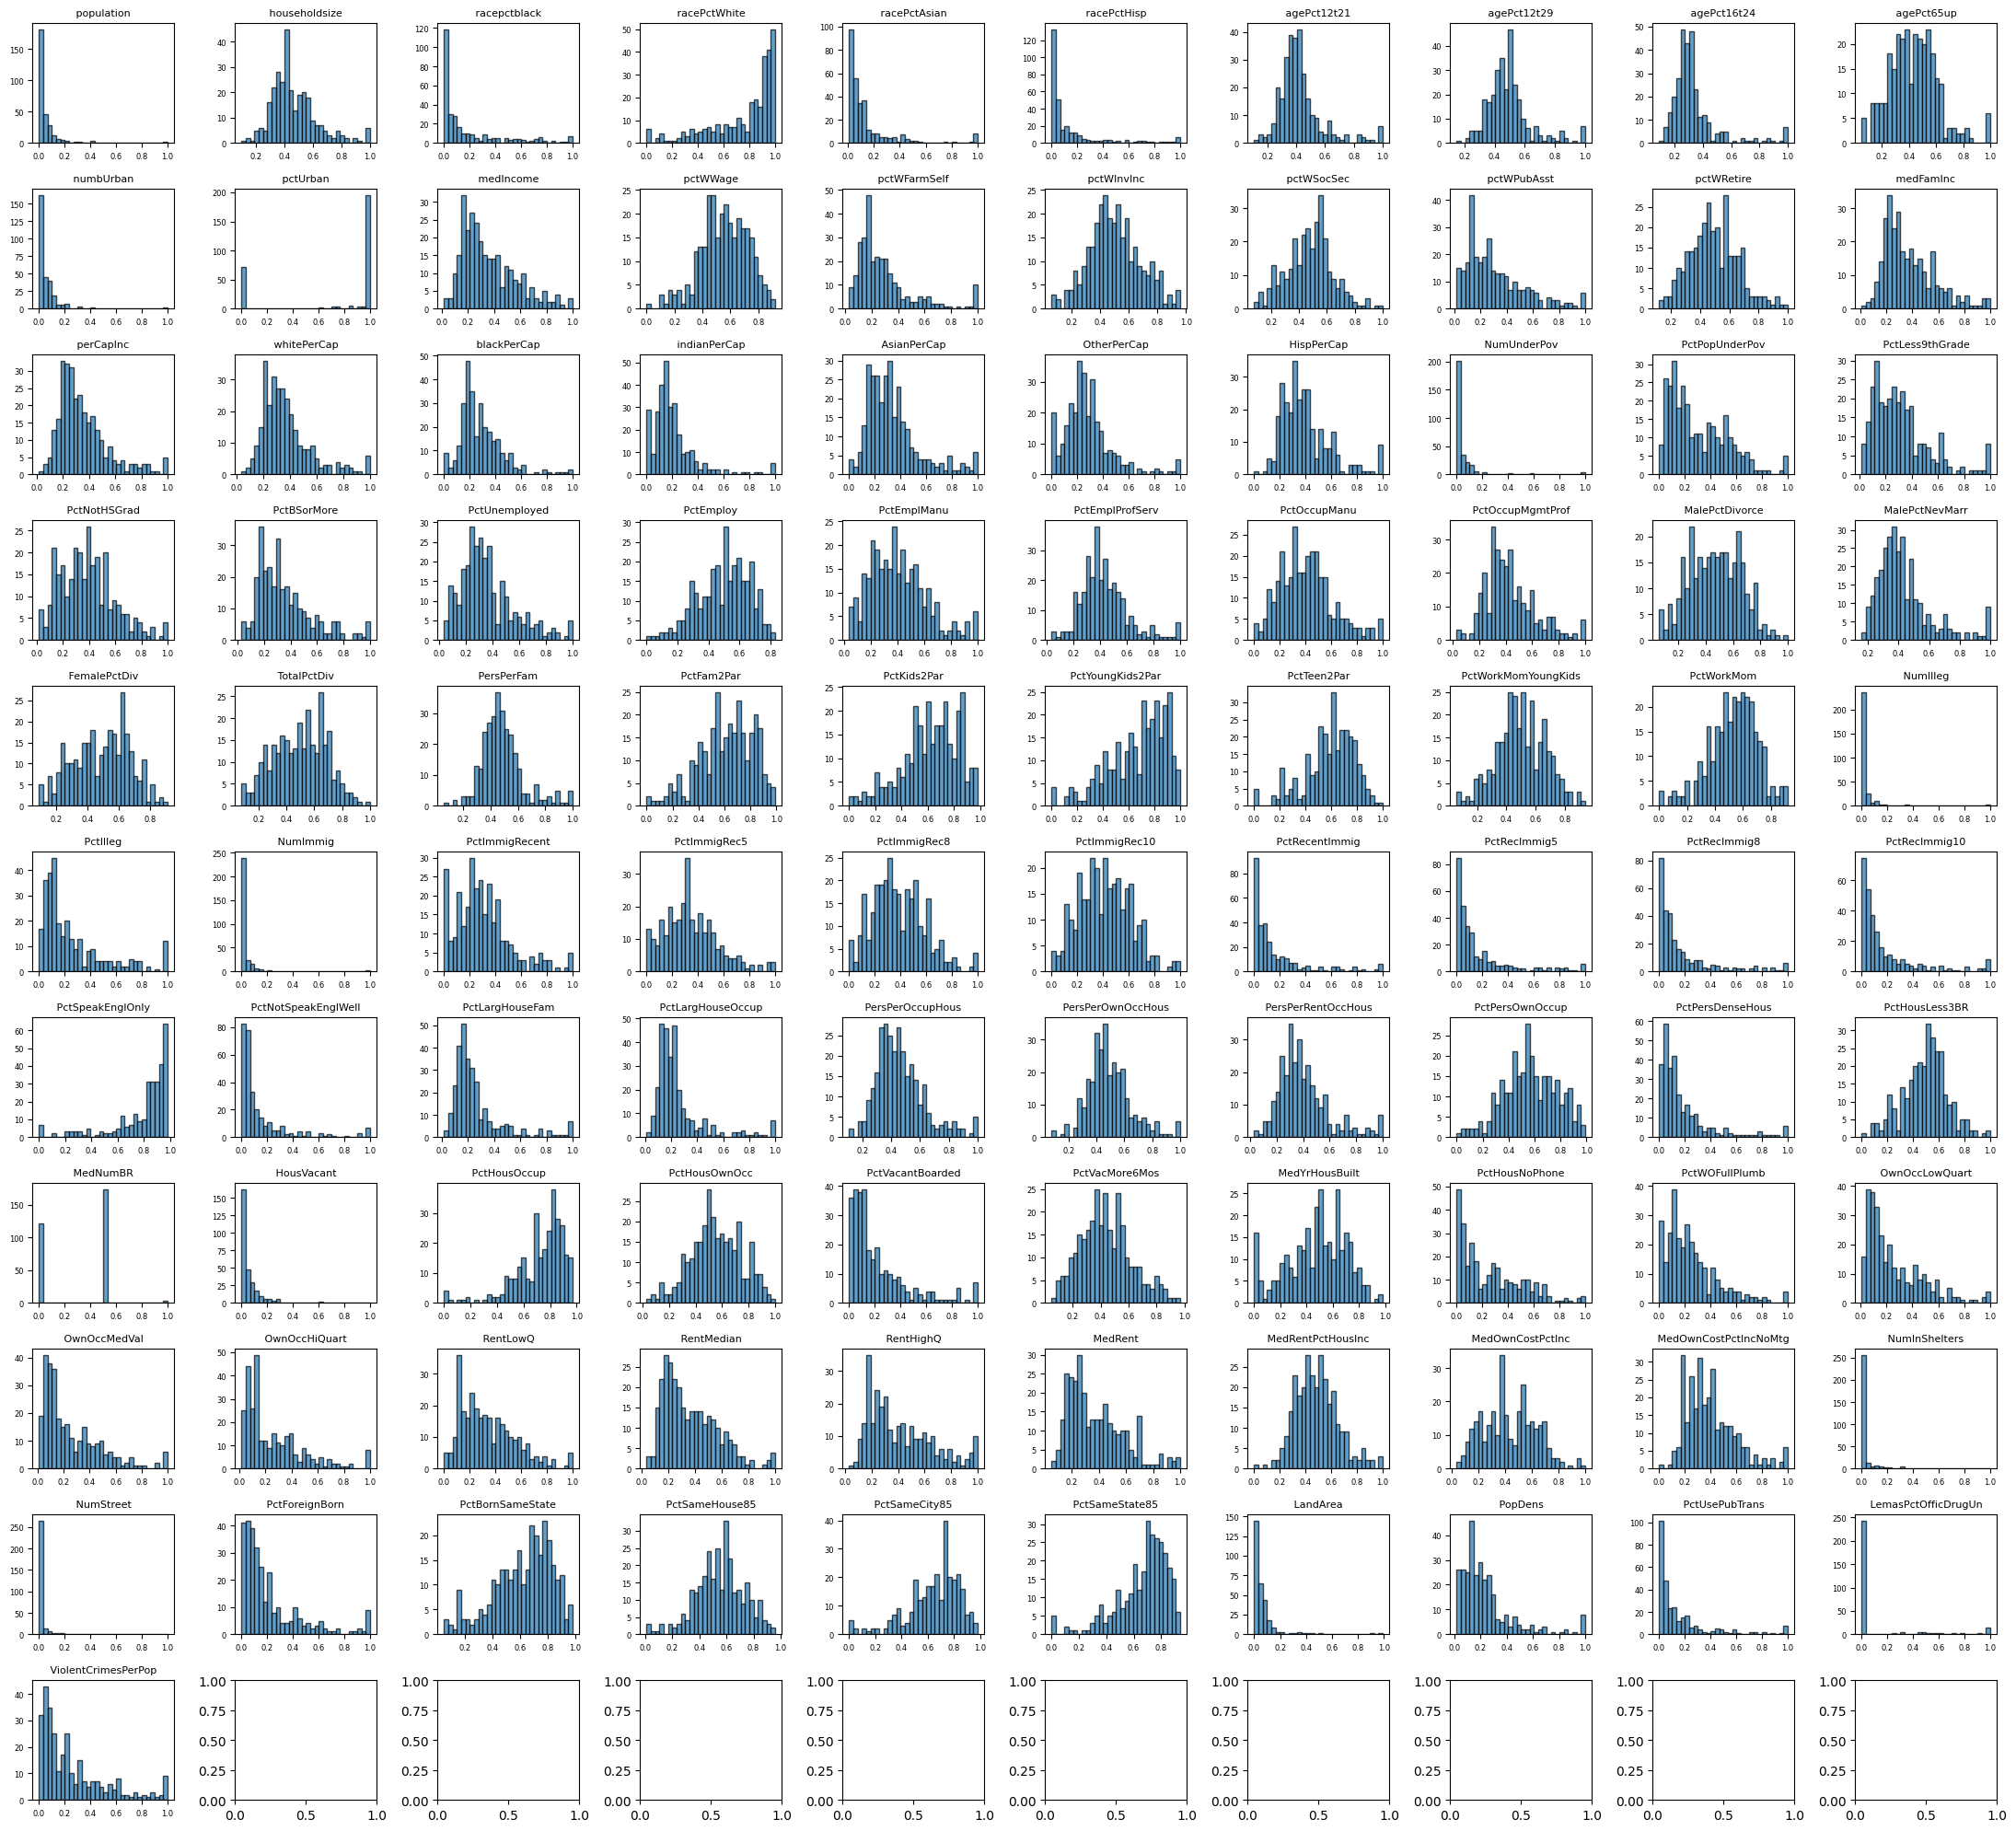

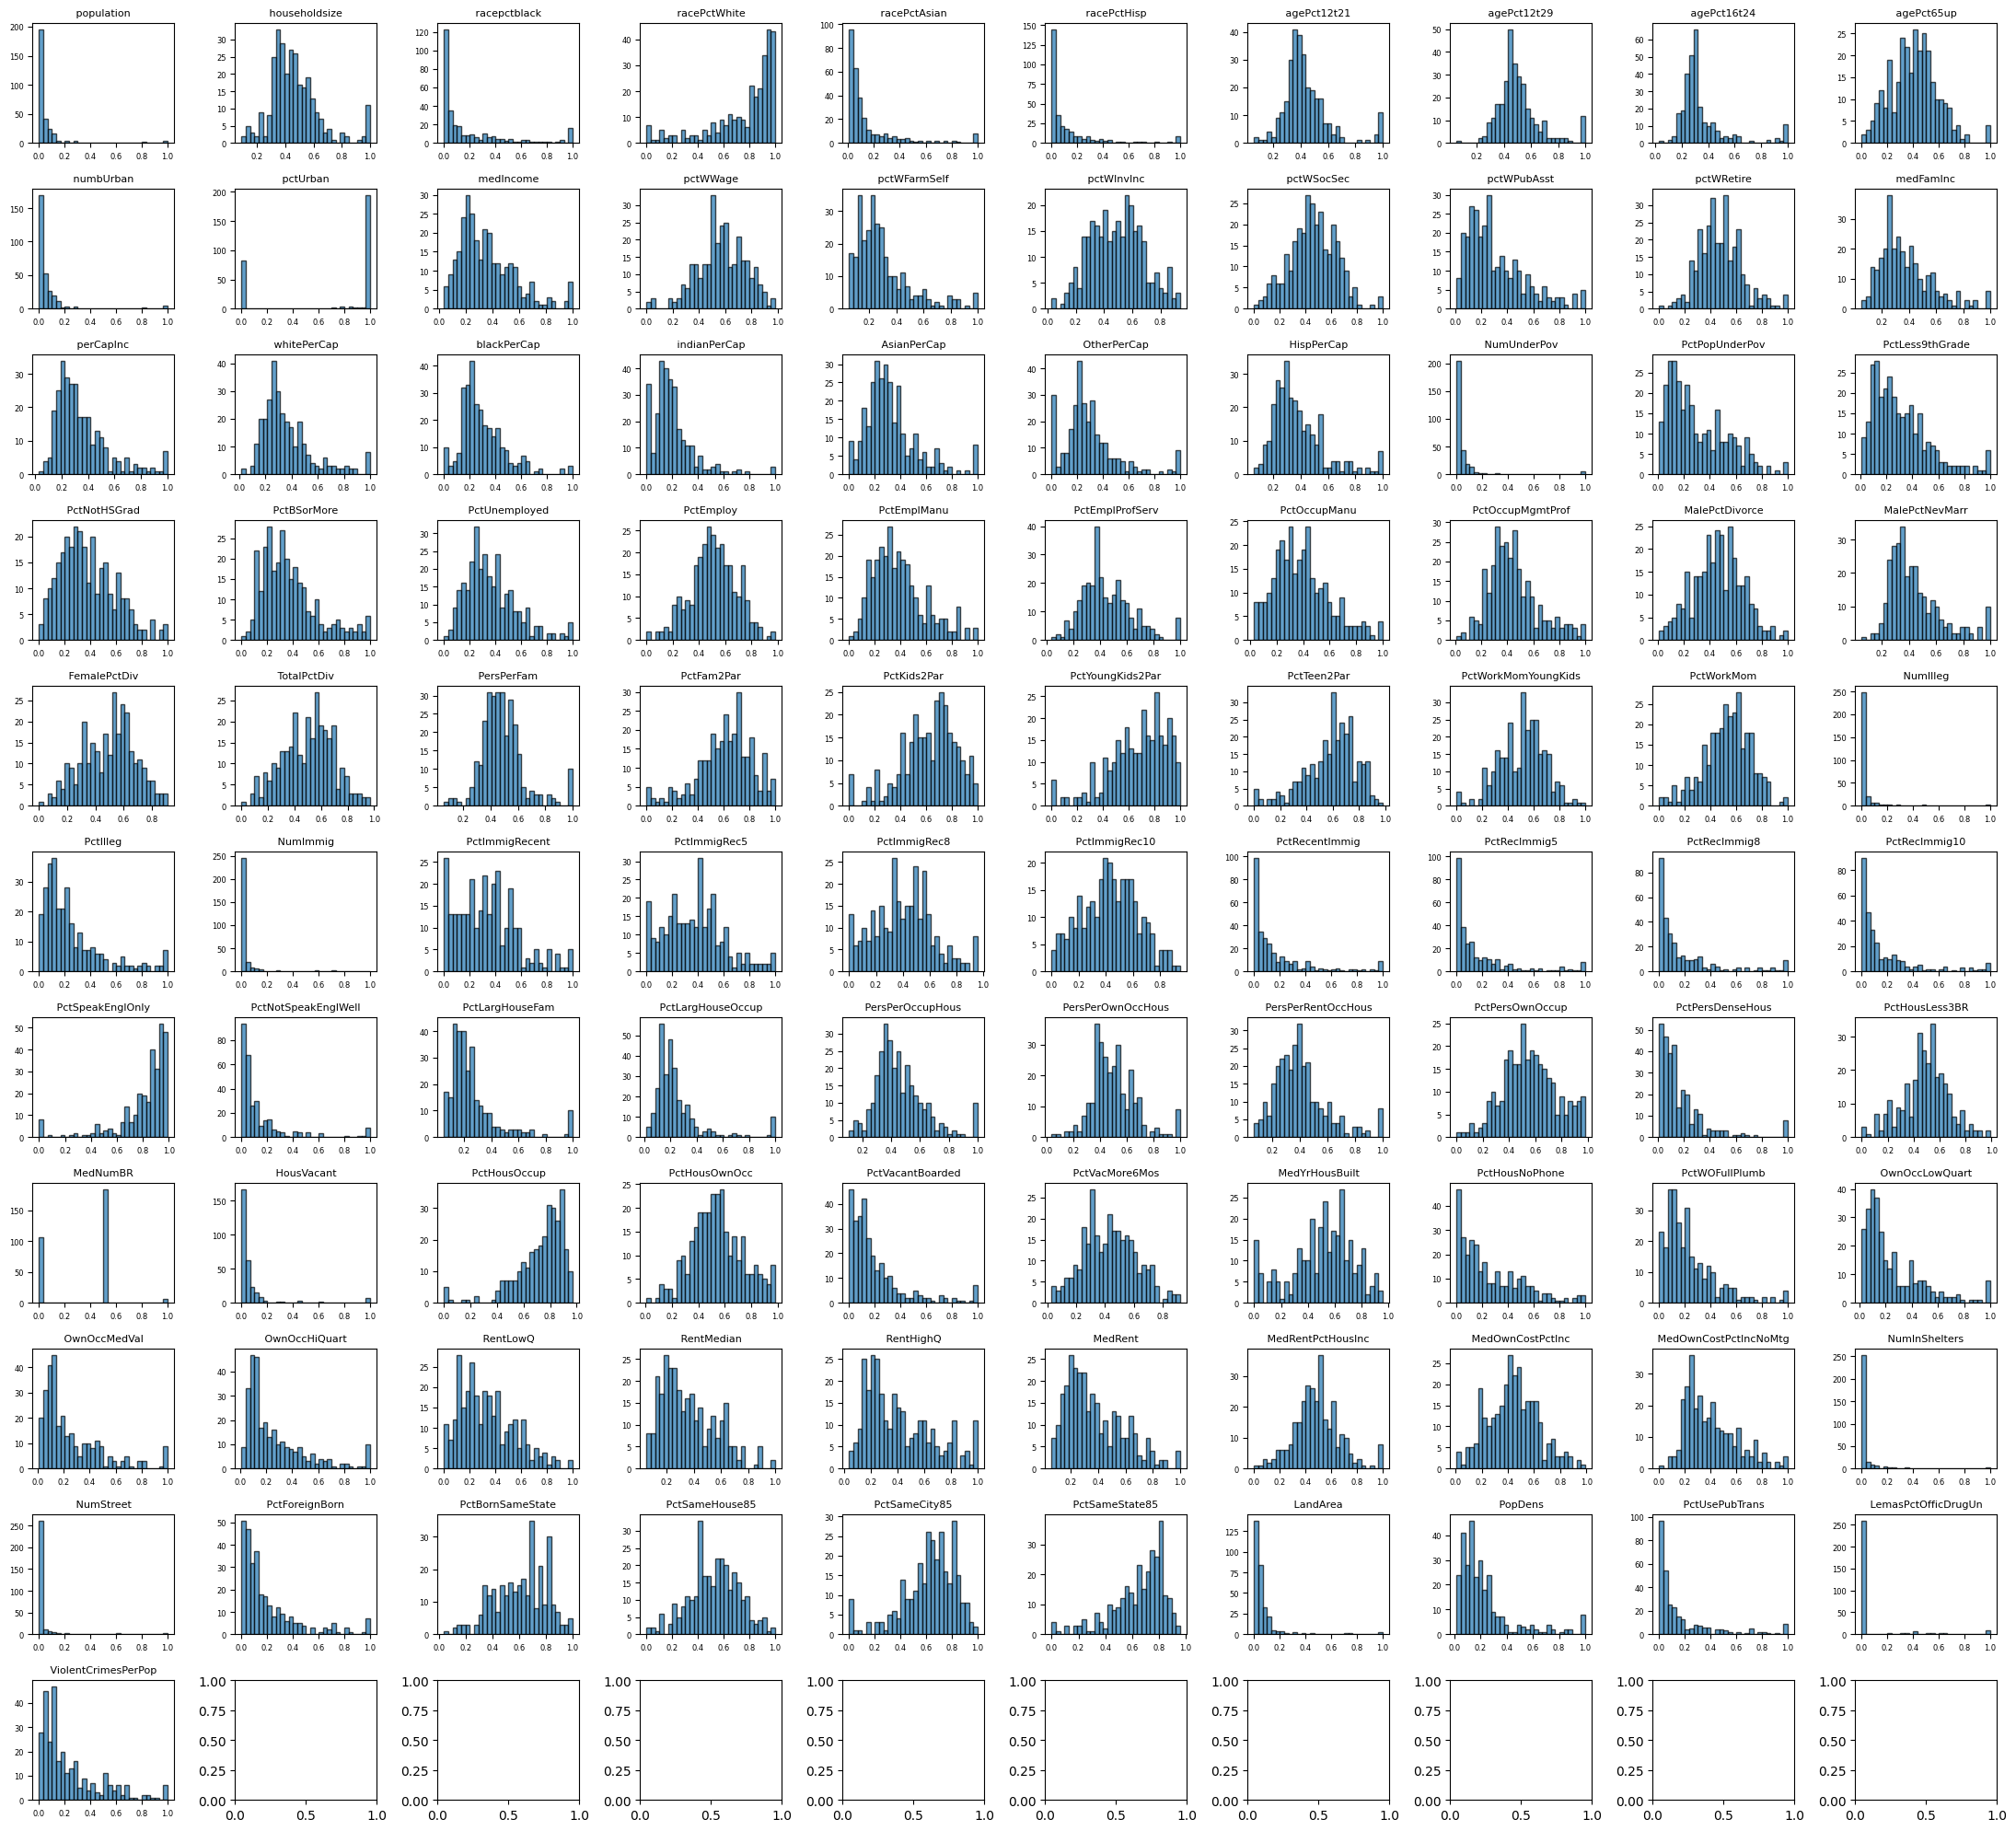

In [126]:
import matplotlib.pyplot as plt

for dataset in [train, val, test]:
    fig, axes = plt.subplots(11, 10, figsize=(22, 20))
    axes = axes.flatten()

    for idx, col in enumerate(dataset.columns):
        axes[idx].hist(dataset[col], bins=30, edgecolor='black', alpha=0.7)
        axes[idx].set_title(col, fontsize=8)
        axes[idx].tick_params(labelsize=6)

    plt.tight_layout()
    plt.show()

#### Interpretation of data distribution plots

As there is a large number of variables (101 input/output var.'s across 3 datasets) it's unreasonable to analyse each data distribution and adjust the skew accordingly, reviewing the distributions at a high level, it can be observed that the distributions remain mostly the same across train, test and val. However the distributions within the dataset vary largely. A universal approach to map data of any distribution to as close to a Gaussian distribution is optimal for this data.

## Pre-processing

The pre-processing uss informed by the Exploratory Data Analysis



The only pre-processing identifiesdequired proeprocessing identified from the Exploratry Daory Data Analysis was a universapl approach to map data tof any distribution to as close to a Gaussian distribution . The selected approach is to useduyse se scikskle[arn 's` `httpPowerTransformer]())https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html

### PowerTransformer

In [127]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer()

# Fit transformer on train set
train_transformed = pd.DataFrame(pt.fit_transform(train), columns=train.columns)

# Transform val and test sets
val_transformed = pd.DataFrame(pt.transform(val), columns=val.columns)
test_transformed = pd.DataFrame(pt.transform(test), columns=test.columns)

# Recreate X and y components for transformed data
X_train = train_transformed.iloc[:,0:-1]
y_train = train_transformed.iloc[:,-1]
X_val = val_transformed.iloc[:,0:-1]
y_val = val_transformed.iloc[:,-1]
X_test = test_transformed.iloc[:,0:-1]
y_test = test_transformed.iloc[:,-1]

## Modelling

We will now model the output using all the available variables

### Linear Regression

In [128]:
# train your Linear Regression model here. Data has already been split into predictors (X_train, X_val and X_test) and the
# desired response (y_train, y_val and y_test above).
#
# Note that you DO NOT NEED to remove any variables, or add higher order terms. JUST USE THE DATA AS IS.
#

# Once you've trained the model, evaluate it. This would include:
#  - Measuring the accuracy of the model (i.e. RMSE or similar measures)
#  - Looking at the properties of the fitted model, for example the R^2, and if all terms are contributing to the model
#  - Considering the validity of the trained model. This could include assumptions about independent predictors, and the 
#    distribution of the residuals
# Your write-up should include your findings regarding the above.

import statsmodels.api as sm

# Fit Linear Regression model
lr_model = sm.OLS(y_train, X_train).fit()

# Make predictions on all sets
y_train_pred = lr_model.predict(X_train)
y_val_pred = lr_model.predict(X_val)
y_test_pred = lr_model.predict(X_test)

#### Evaluate Linear Regression model

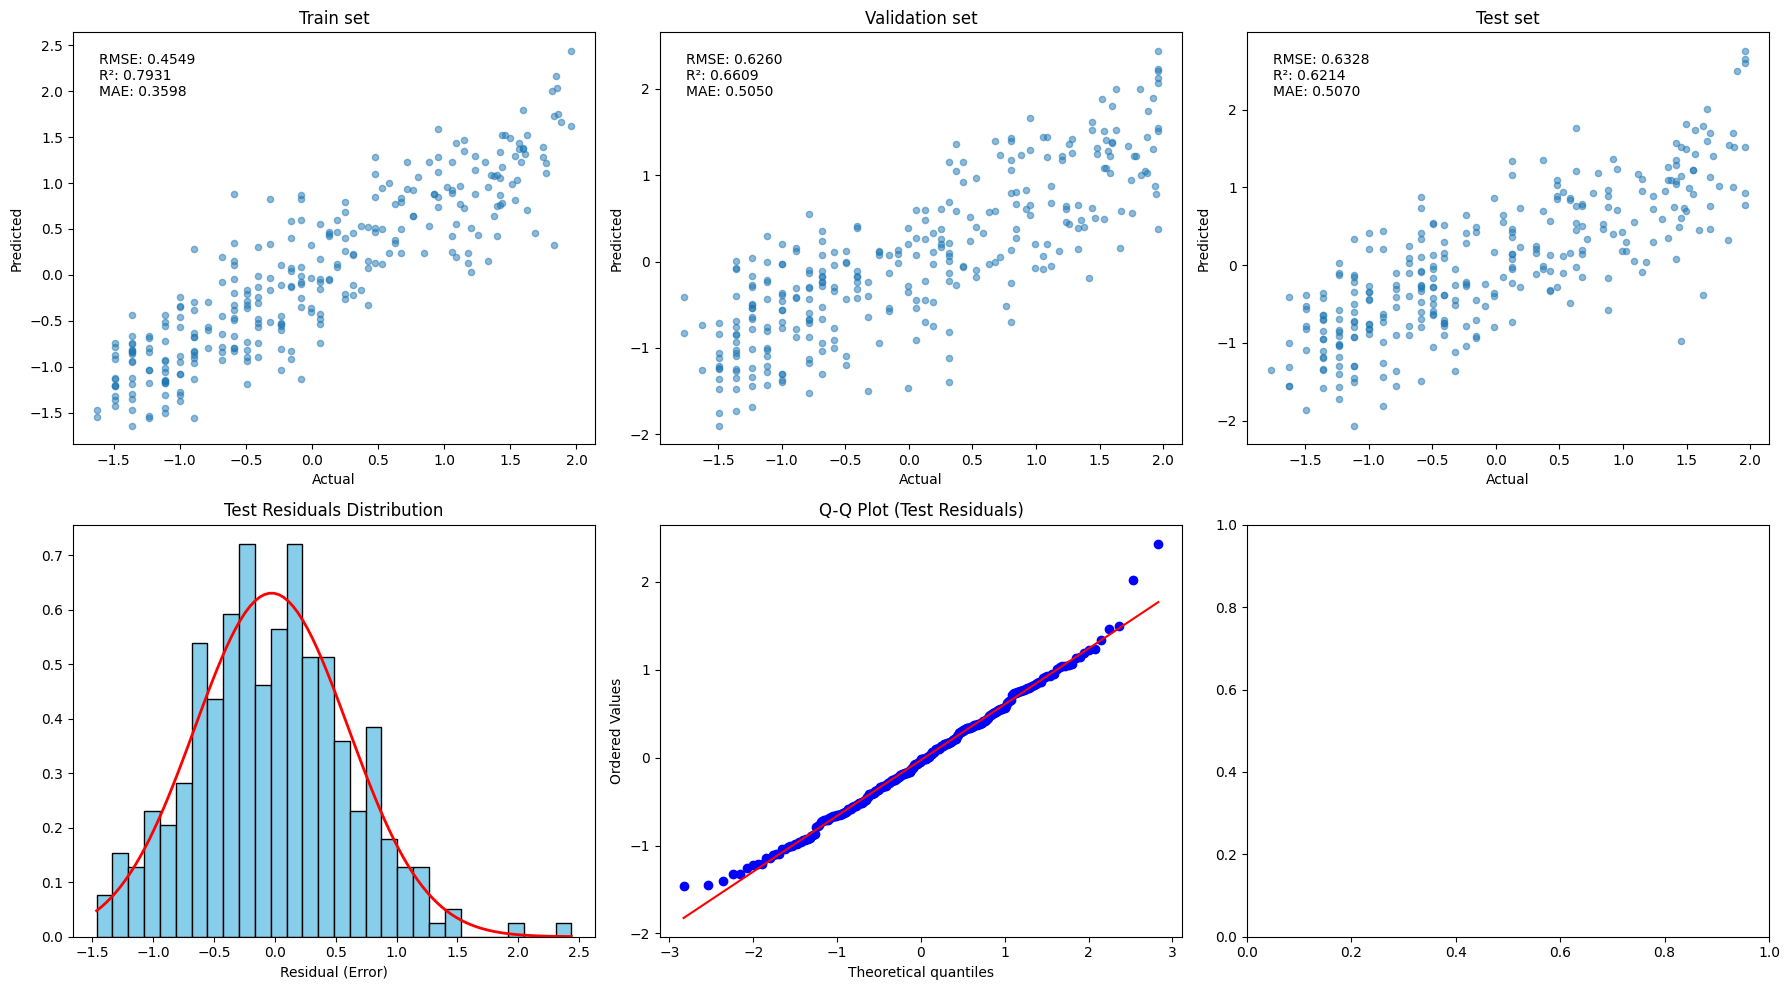

Linear Regression Test set metrics:
RMSE: 0.6328
R²: 0.6214
MAE: 0.5070


In [129]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import scipy.stats as stats

# Calculate evaluation metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_res = y_train - y_train_pred
val_res = y_val - y_val_pred
test_res = y_test - y_test_pred

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

datasets = [
    (y_train, y_train_pred, f'Train set', f'RMSE: {train_rmse:.4f}\nR²: {train_r2:.4f}\nMAE: {train_mae:.4f}', axes[0, 0]),
    (y_val, y_val_pred, f'Validation set', f'RMSE: {val_rmse:.4f}\nR²: {val_r2:.4f}\nMAE: {val_mae:.4f}', axes[0, 1]),
    (y_test, y_test_pred, f'Test set', f'RMSE: {test_rmse:.4f}\nR²: {test_r2:.4f}\nMAE: {test_mae:.4f}', axes[0, 2])
]

for actual, pred, title, text, ax in datasets:
    ax.scatter(actual, pred, alpha=0.5, s=20)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(title)
    ax.text(0.05, 0.95, text, transform=ax.transAxes, verticalalignment='top')

axes[1, 0].hist(test_res, bins=30, color='skyblue', edgecolor='black', density=True)
axes[1, 0].set_title('Test Residuals Distribution')
axes[1, 0].set_xlabel('Residual (Error)')

# Overlay Normal Distribution Curve
mu, std = stats.norm.fit(test_res)
x = np.linspace(test_res.min(), test_res.max(), 100)
p = stats.norm.pdf(x, mu, std)
axes[1, 0].plot(x, p, 'r', linewidth=2)

# Q-Q Plot
stats.probplot(test_res, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Test Residuals)')

plt.tight_layout()
plt.show()

linear_regression_test_set_metrics = f"Linear Regression Test set metrics:\n{datasets[2][3]}"

print(linear_regression_test_set_metrics)

### Regularised Models

In [130]:
# train your regularised models (ridge and lasso). Here you will use the same data as you used in for the above regression model
#
# One key consideration with your regularised models is the selection of lambda (i.e. the strength of the regularisation). A suggested 
# starting point for finding your value of lambda is suggested below using numpy.logspace (see 
# https://numpy.org/doc/stable/reference/generated/numpy.logspace.html). The code below will give you 50 values starting at 10-10 and 
# finishing at 1, spread on a log scale. Just note that for plotting things that result from this, you may want to change the scale of 
# your x-axis to a log scale (see https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xscale.html)
#
# Note that the below list of lambda is going to be fairly coarse. For the sake of speed, we suggest that you avoid evaluating a huge
# number of lambdas in one pass, but you can get a more precise estimate by refining your estimate over multiple passes (i.e. if your
# initial estimate if 0.1, you could run the search again now looking over a range of [0.01 .. 1.0] or similar). If you wish to do this,
# we suggest limiting yourself to 2-3 passes at most. You do not need to get the perfect value of lambda.
#
# remember that lambda is a keyword in python, so we're calling the array below alphas. 
#
alphas = np.logspace(-5, 5, 100)

# Once you've found your ridge and lasso models, evaluate them, following the approach you've used for the linear method, and compare the
# three models.

#### Ridge Regression

In [131]:
rmse_train_rr = []
rmse_val_rr = []
rmse_test_rr = []
coeffs_rr = []

for a in alphas:
    rr_model = sm.OLS(y_train, X_train).fit_regularized(alpha=a, L1_wt=0)

    y_train_pred_rr = rr_model.predict(X_train)
    y_val_pred_rr = rr_model.predict(X_val)
    y_test_pred_rr = rr_model.predict(X_test)

    rmse_train_rr.append(np.sqrt(mean_squared_error(y_train, y_train_pred_rr)))
    rmse_val_rr.append(np.sqrt(mean_squared_error(y_val, y_val_pred_rr)))
    rmse_test_rr.append(np.sqrt(mean_squared_error(y_test, y_test_pred_rr)))
    coeffs_rr.append(rr_model.params)

##### Evaluate alpha values for Ridge Regression

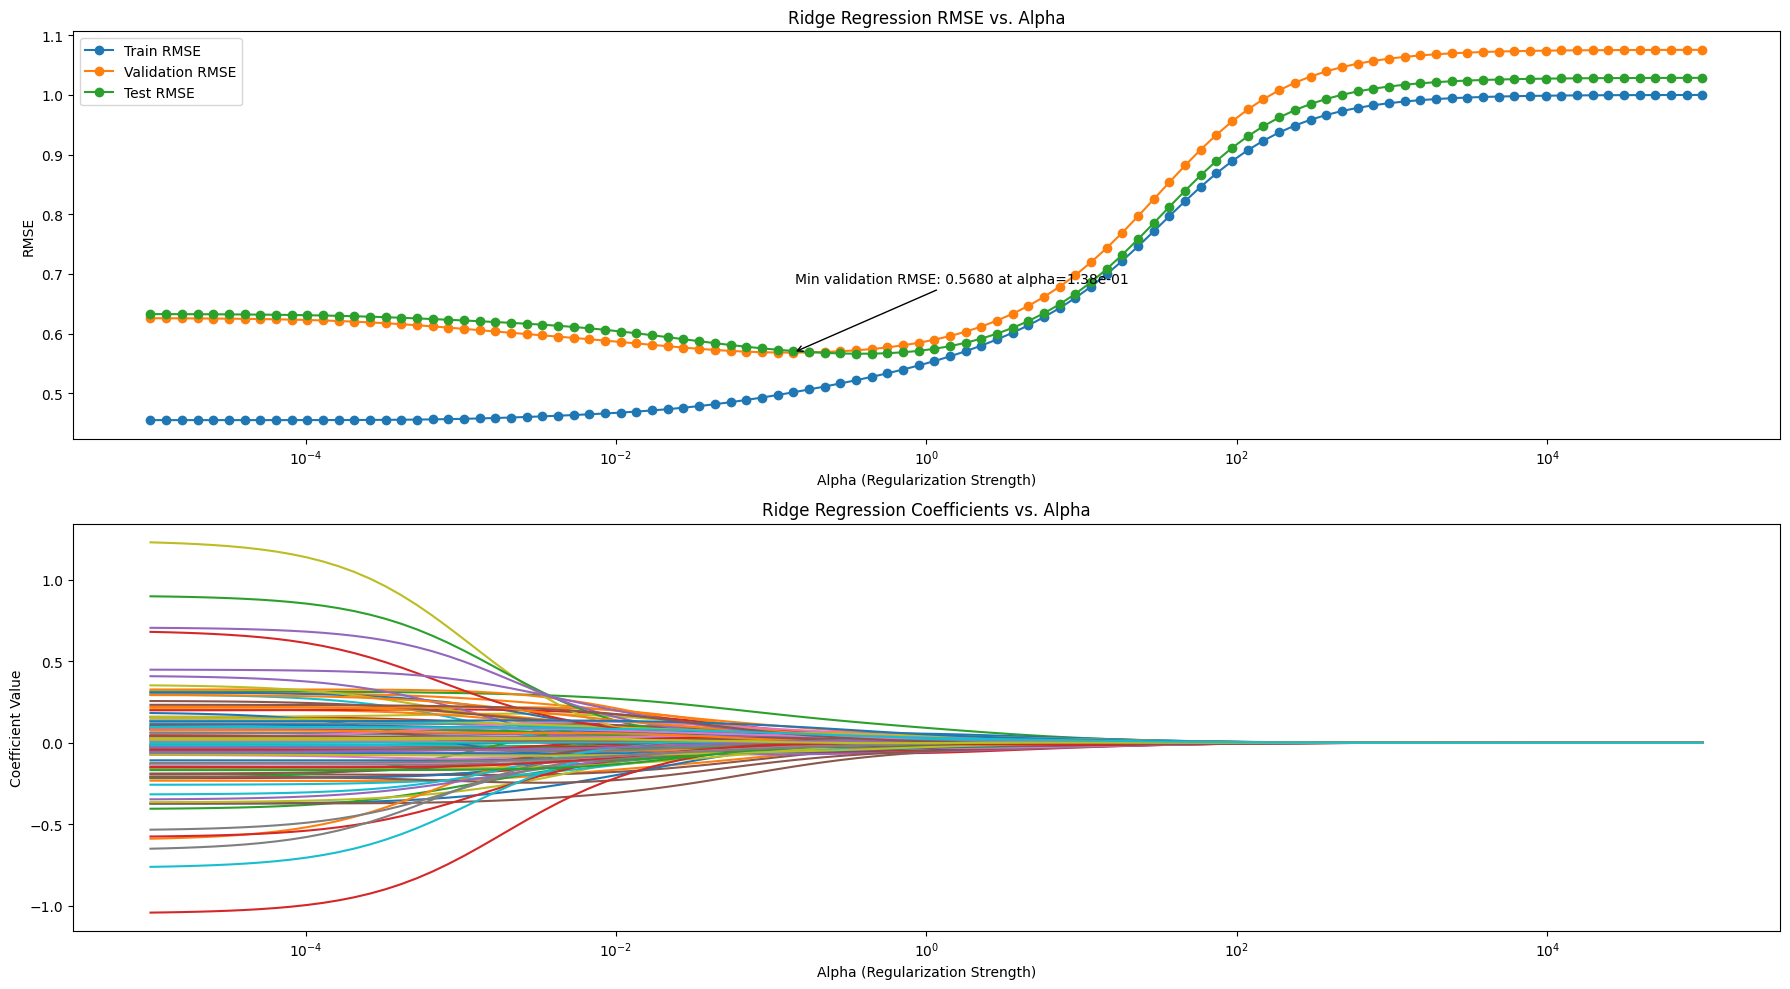

In [132]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

for rmse, label in zip(
    [rmse_train_rr, rmse_val_rr, rmse_test_rr], 
    ['Train RMSE', 'Validation RMSE', 'Test RMSE']
    ):
    axes[0].plot(alphas, rmse, label=label, marker='o')

axes[0].annotate(
    f"Min validation RMSE: {min(rmse_val_rr):.4f} at alpha={alphas[np.argmin(rmse_val_rr)]:.2e}", 
    xy=(alphas[np.argmin(rmse_val_rr)], min(rmse_val_rr)), 
    xytext=(1, 50), 
    textcoords='offset points', 
    arrowprops=dict(arrowstyle='->')
    )
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (Regularization Strength)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Ridge Regression RMSE vs. Alpha')
axes[0].legend()
axes[1].plot(alphas, coeffs_rr)
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (Regularization Strength)')
axes[1].set_ylabel('Coefficient Value')
axes[1].set_title('Ridge Regression Coefficients vs. Alpha')

plt.tight_layout()
plt.show()

best_alpha_rr = alphas[np.argmin(rmse_val_rr)]

##### Evaluate Ridge Regression model

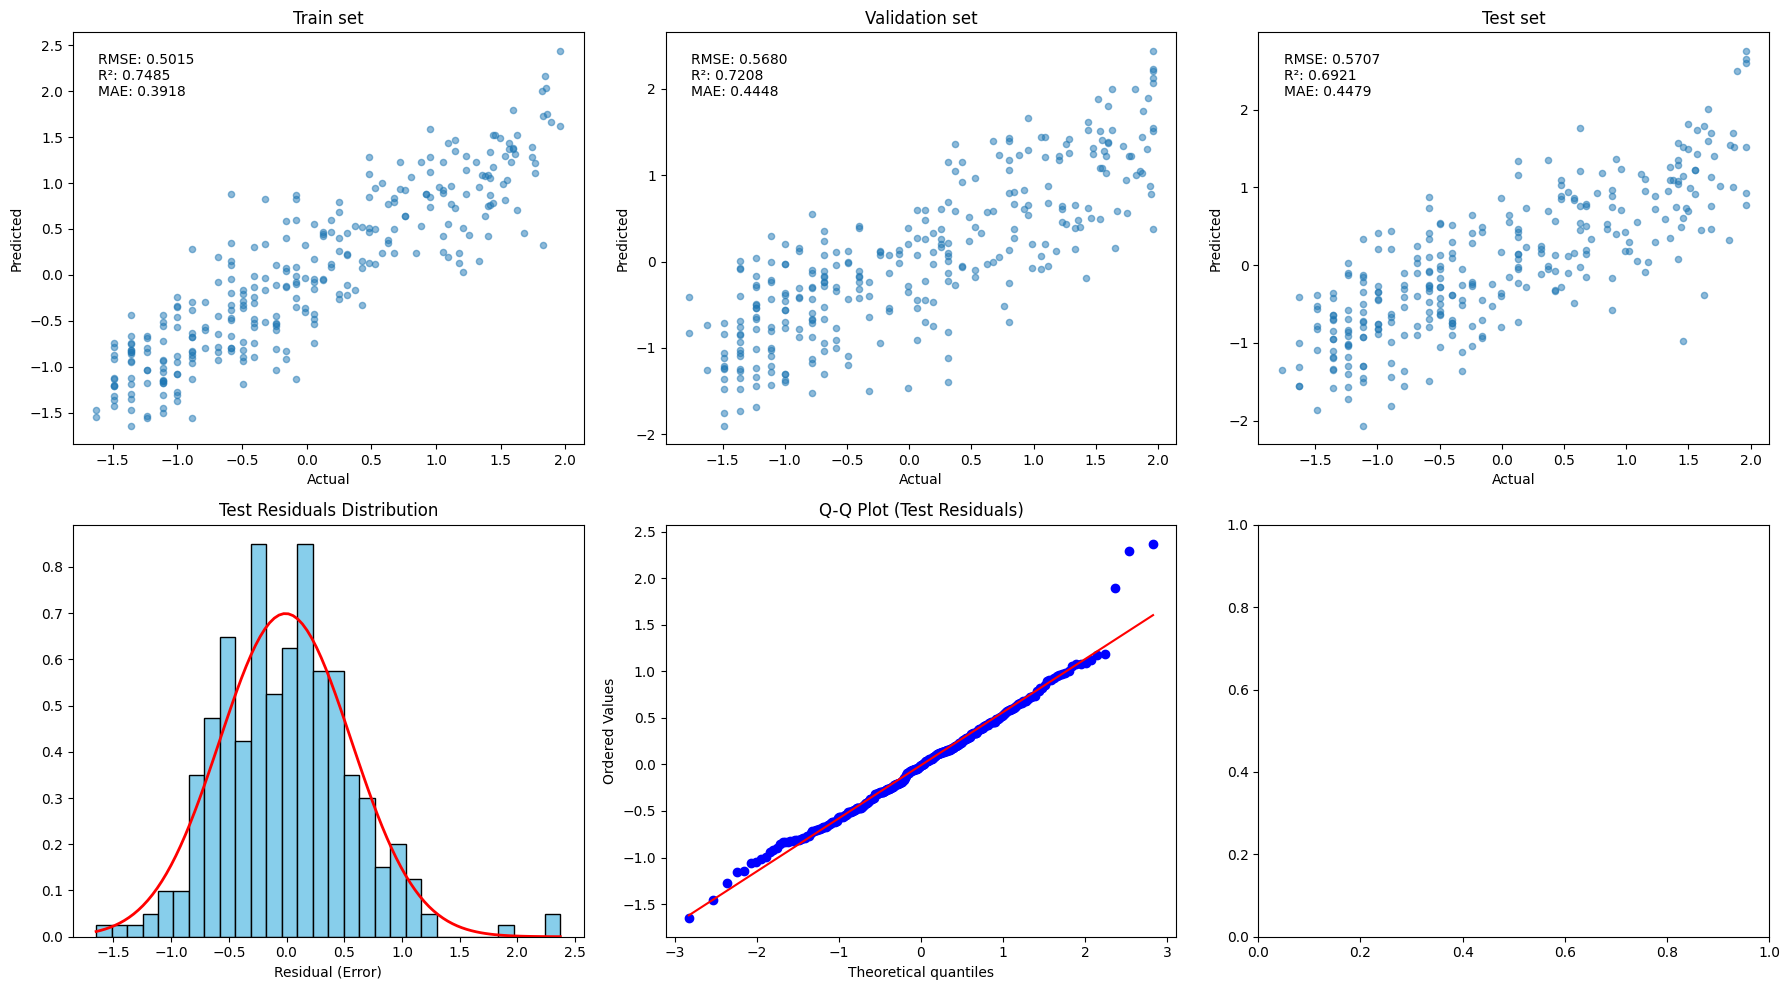

Ridge Regression Test set metrics:
RMSE: 0.5707
R²: 0.6921
MAE: 0.4479


In [133]:
rr_model = sm.OLS(y_train, X_train).fit_regularized(alpha=best_alpha_rr, L1_wt=0)

y_train_pred_rr = rr_model.predict(X_train)
y_val_pred_rr = rr_model.predict(X_val)
y_test_pred_rr = rr_model.predict(X_test)

# Calculate evaluation metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rr))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_rr))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rr))

train_r2 = r2_score(y_train, y_train_pred_rr)
val_r2 = r2_score(y_val, y_val_pred_rr)
test_r2 = r2_score(y_test, y_test_pred_rr)

train_mae = mean_absolute_error(y_train, y_train_pred_rr)
val_mae = mean_absolute_error(y_val, y_val_pred_rr)
test_mae = mean_absolute_error(y_test, y_test_pred_rr)

train_res = y_train - y_train_pred_rr
val_res = y_val - y_val_pred_rr
test_res = y_test - y_test_pred_rr

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

datasets = [
    (y_train, y_train_pred, f'Train set', f'RMSE: {train_rmse:.4f}\nR²: {train_r2:.4f}\nMAE: {train_mae:.4f}', axes[0, 0]),
    (y_val, y_val_pred, f'Validation set', f'RMSE: {val_rmse:.4f}\nR²: {val_r2:.4f}\nMAE: {val_mae:.4f}', axes[0, 1]),
    (y_test, y_test_pred, f'Test set', f'RMSE: {test_rmse:.4f}\nR²: {test_r2:.4f}\nMAE: {test_mae:.4f}', axes[0, 2])
]

for actual, pred, title, text, ax in datasets:
    ax.scatter(actual, pred, alpha=0.5, s=20)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(title)
    ax.text(0.05, 0.95, text, transform=ax.transAxes, verticalalignment='top')

axes[1, 0].hist(test_res, bins=30, color='skyblue', edgecolor='black', density=True)
axes[1, 0].set_title('Test Residuals Distribution')
axes[1, 0].set_xlabel('Residual (Error)')

# Overlay Normal Distribution Curve
mu, std = stats.norm.fit(test_res)
x = np.linspace(test_res.min(), test_res.max(), 100)
p = stats.norm.pdf(x, mu, std)
axes[1, 0].plot(x, p, 'r', linewidth=2)

# Q-Q Plot
stats.probplot(test_res, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Test Residuals)')

plt.tight_layout()
plt.show()

ridge_regression_test_set_metrics = f"Ridge Regression Test set metrics:\n{datasets[2][3]}"

print(ridge_regression_test_set_metrics)

#### Lasso Regression

In [134]:
rmse_train_lar = []
rmse_val_lar = []
rmse_test_lar = []
coeffs_lar = []

for a in alphas:
    lar_model = sm.OLS(y_train, X_train).fit_regularized(alpha=a, L1_wt=1)

    y_train_pred_lar = lar_model.predict(X_train)
    y_val_pred_lar = lar_model.predict(X_val)
    y_test_pred_lar = lar_model.predict(X_test)

    rmse_train_lar.append(np.sqrt(mean_squared_error(y_train, y_train_pred_lar)))
    rmse_val_lar.append(np.sqrt(mean_squared_error(y_val, y_val_pred_lar)))
    rmse_test_lar.append(np.sqrt(mean_squared_error(y_test, y_test_pred_lar)))
    coeffs_lar.append(lar_model.params)

##### Evaluate alpha values for Lasso Regression

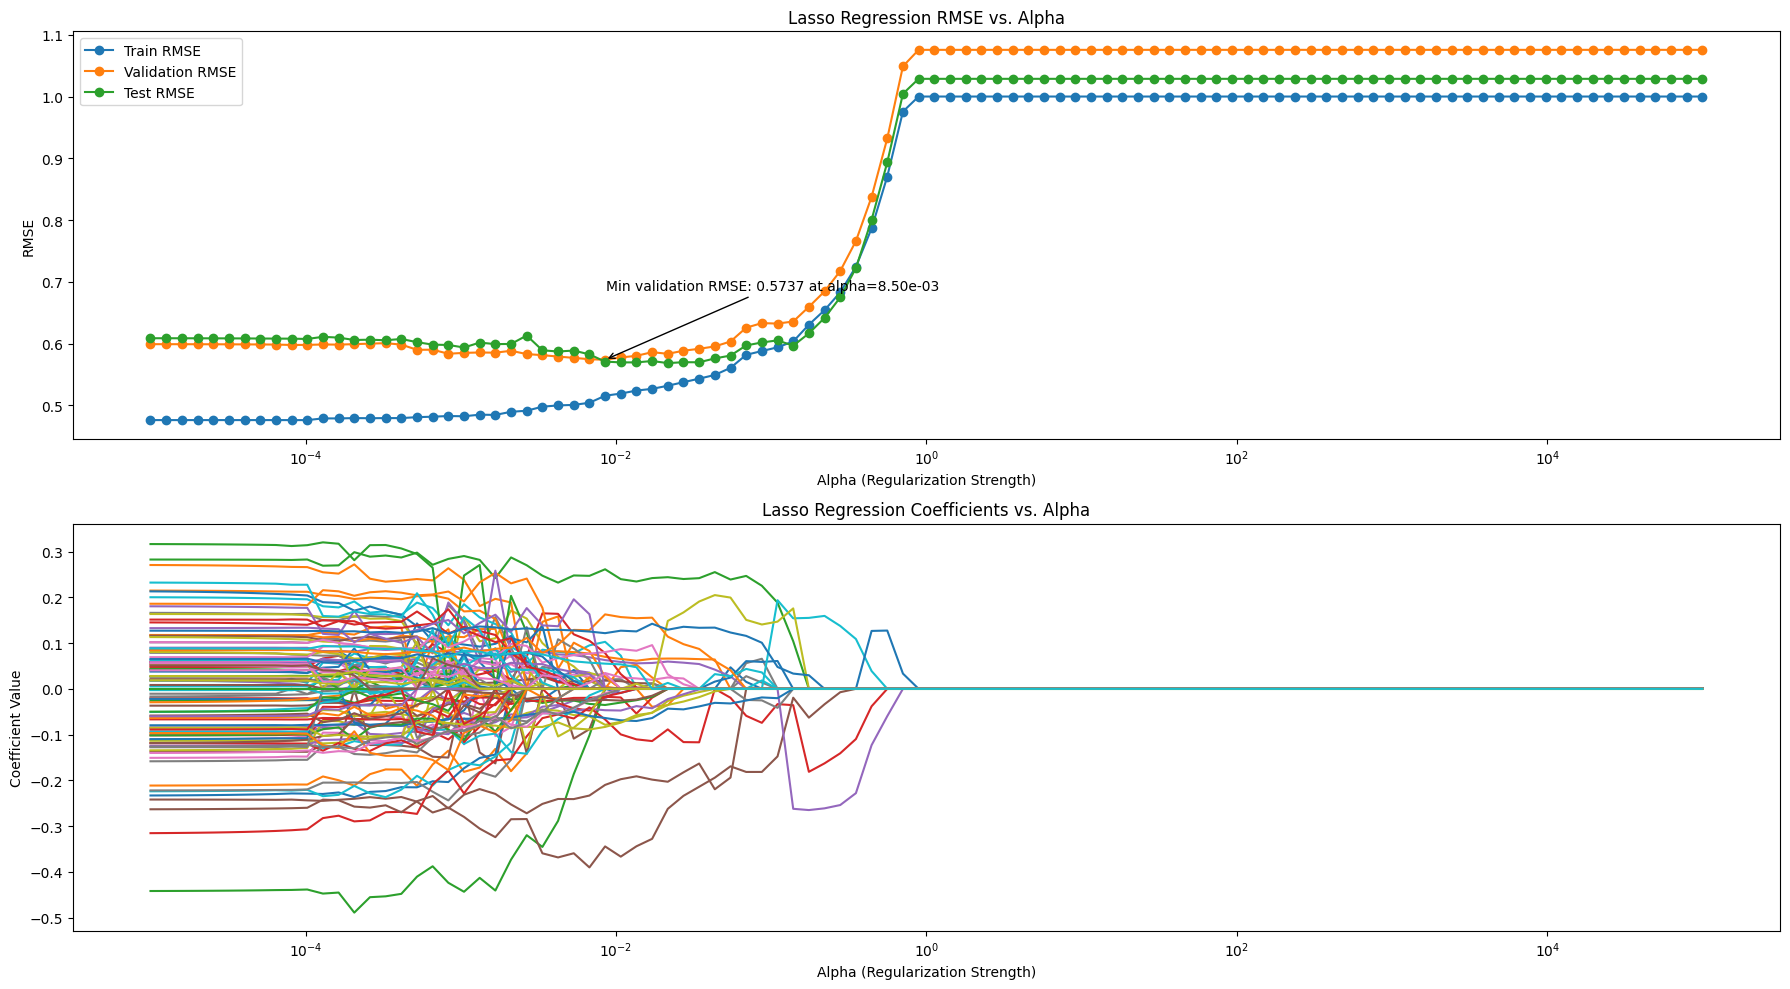

In [135]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

for rmse, label in zip(
    [rmse_train_lar, rmse_val_lar, rmse_test_lar], 
    ['Train RMSE', 'Validation RMSE', 'Test RMSE']
    ):
    axes[0].plot(alphas, rmse, label=label, marker='o')

axes[0].annotate(
    f"Min validation RMSE: {min(rmse_val_lar):.4f} at alpha={alphas[np.argmin(rmse_val_lar)]:.2e}", 
    xy=(alphas[np.argmin(rmse_val_lar)], min(rmse_val_lar)), 
    xytext=(1, 50), 
    textcoords='offset points', 
    arrowprops=dict(arrowstyle='->')
    )
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (Regularization Strength)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Lasso Regression RMSE vs. Alpha')
axes[0].legend()
axes[1].plot(alphas, coeffs_lar)
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (Regularization Strength)')
axes[1].set_ylabel('Coefficient Value')
axes[1].set_title('Lasso Regression Coefficients vs. Alpha')

plt.tight_layout()
plt.show()

best_alpha_lar = alphas[np.argmin(rmse_val_lar)]

##### Evaluate Lasso Regression model

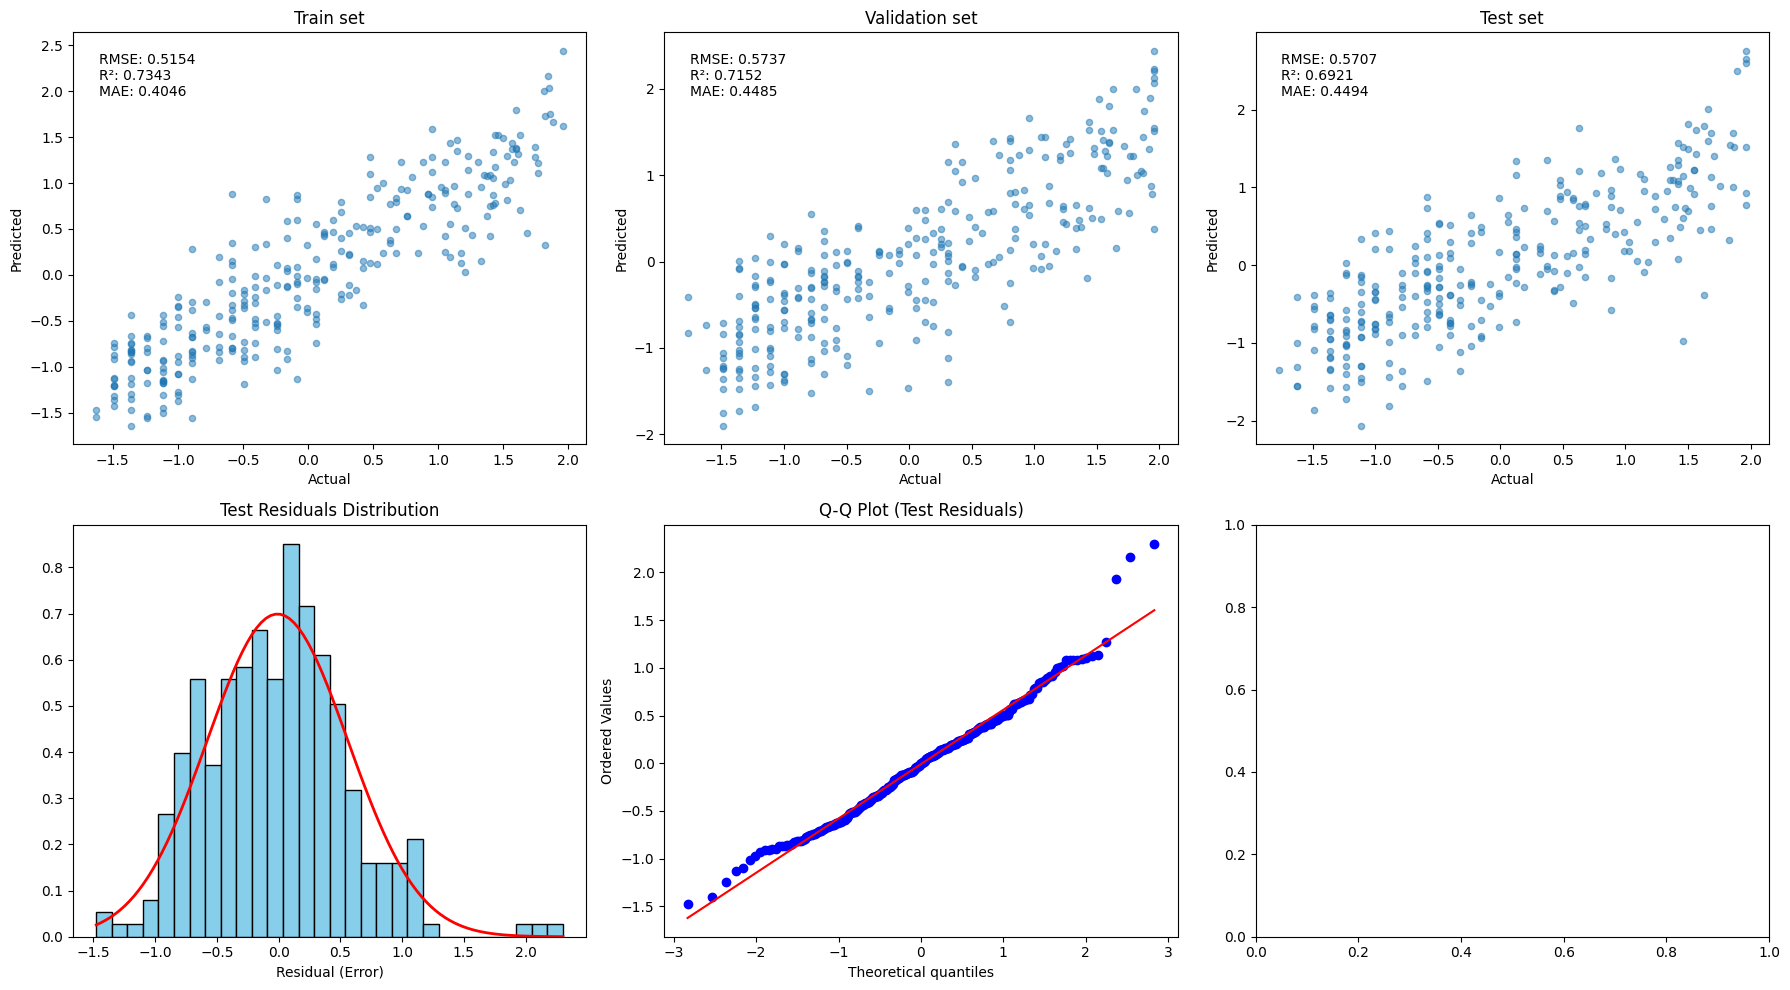

Lasso Regression Test set metrics:
RMSE: 0.5707
R²: 0.6921
MAE: 0.4494


In [136]:
lar_model = sm.OLS(y_train, X_train).fit_regularized(alpha=best_alpha_lar, L1_wt=1)

y_train_pred_lar = lar_model.predict(X_train)
y_val_pred_lar = lar_model.predict(X_val)
y_test_pred_lar = lar_model.predict(X_test)

# Calculate evaluation metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lar))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_lar))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lar))

train_r2 = r2_score(y_train, y_train_pred_lar)
val_r2 = r2_score(y_val, y_val_pred_lar)
test_r2 = r2_score(y_test, y_test_pred_lar)

train_mae = mean_absolute_error(y_train, y_train_pred_lar)
val_mae = mean_absolute_error(y_val, y_val_pred_lar)
test_mae = mean_absolute_error(y_test, y_test_pred_lar)

train_res = y_train - y_train_pred_lar
val_res = y_val - y_val_pred_lar
test_res = y_test - y_test_pred_lar

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

datasets = [
    (y_train, y_train_pred, f'Train set', f'RMSE: {train_rmse:.4f}\nR²: {train_r2:.4f}\nMAE: {train_mae:.4f}', axes[0, 0]),
    (y_val, y_val_pred, f'Validation set', f'RMSE: {val_rmse:.4f}\nR²: {val_r2:.4f}\nMAE: {val_mae:.4f}', axes[0, 1]),
    (y_test, y_test_pred, f'Test set', f'RMSE: {test_rmse:.4f}\nR²: {test_r2:.4f}\nMAE: {test_mae:.4f}', axes[0, 2])
]

for actual, pred, title, text, ax in datasets:
    ax.scatter(actual, pred, alpha=0.5, s=20)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(title)
    ax.text(0.05, 0.95, text, transform=ax.transAxes, verticalalignment='top')

axes[1, 0].hist(test_res, bins=30, color='skyblue', edgecolor='black', density=True)
axes[1, 0].set_title('Test Residuals Distribution')
axes[1, 0].set_xlabel('Residual (Error)')

# Overlay Normal Distribution Curve
mu, std = stats.norm.fit(test_res)
x = np.linspace(test_res.min(), test_res.max(), 100)
p = stats.norm.pdf(x, mu, std)
axes[1, 0].plot(x, p, 'r', linewidth=2)

# Q-Q Plot
stats.probplot(test_res, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Test Residuals)')

plt.tight_layout()
plt.show()

lasso_regression_test_set_metrics = f"Lasso Regression Test set metrics:\n{datasets[2][3]}"
print(lasso_regression_test_set_metrics)

## Comparing Modelling approaches

In [138]:
print("Linear Regression:\n" + linear_regression_test_set_metrics + "\n\n" +
      "Ridge Regression:\n" + ridge_regression_test_set_metrics + "\n\n" +
      "Lasso Regression:\n" + lasso_regression_test_set_metrics)

Linear Regression:
Linear Regression Test set metrics:
RMSE: 0.6328
R²: 0.6214
MAE: 0.5070

Ridge Regression:
Ridge Regression Test set metrics:
RMSE: 0.5707
R²: 0.6921
MAE: 0.4479

Lasso Regression:
Lasso Regression Test set metrics:
RMSE: 0.5707
R²: 0.6921
MAE: 0.4494
